# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** HAMKA PUTRA ANDIYAN
**NIM:** 122140121

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


In [49]:
!pip install opencv-python mediapipe numpy matplotlib


  Using cached mediapipe-0.10.21-cp311-cp311-win_amd64.whl (51.0 MB)
  Using cached absl_py-2.3.1-py3-none-any.whl (135 kB)
  Using cached attrs-25.4.0-py3-none-any.whl (67 kB)
  Using cached jax-0.8.0-py3-none-any.whl (2.9 MB)
  Using cached jaxlib-0.8.0-cp311-cp311-win_amd64.whl (59.3 MB)
  Using cached mediapipe-0.10.20-cp311-cp311-win_amd64.whl (51.0 MB)
  Using cached mediapipe-0.10.18-cp311-cp311-win_amd64.whl (50.9 MB)
  Using cached mediapipe-0.10.14-cp311-cp311-win_amd64.whl (50.8 MB)
  Using cached opencv_contrib_python-4.12.0.88-cp37-abi3-win_amd64.whl (45.3 MB)
  Using cached sounddevice-0.5.3-py3-none-win_amd64.whl (364 kB)
  Using cached cffi-2.0.0-cp311-cp311-win_amd64.whl (182 kB)
  Using cached ml_dtypes-0.5.3-cp311-cp311-win_amd64.whl (206 kB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\unnom\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


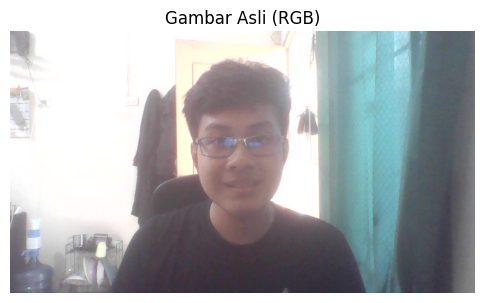

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar (OpenCV baca dalam format BGR)
img_bgr = cv2.imread("selfie.jpg")

if img_bgr is None:
    raise FileNotFoundError("File 'selfie.jpg' tidak ditemukan. Pastikan ada di folder yang sama dengan notebook.")

# Konversi ke RGB agar benar saat ditampilkan dengan matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Gambar Asli (RGB)")
plt.axis("off")
plt.show()


### Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

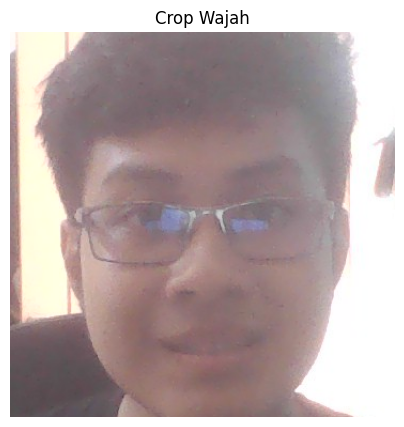

In [ ]:
# Cropping wajah (koordinat sudah disesuaikan)
x_face = 450
y_face = 130
side  = 360

face_crop_bgr = img_bgr[y_face:y_face+side, x_face:x_face+side]
face_crop_rgb = cv2.cvtColor(face_crop_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(face_crop_rgb)
plt.title("Crop Wajah")
plt.axis("off")
plt.show()


### Cropping **persegi panjang pada area latar belakang**.

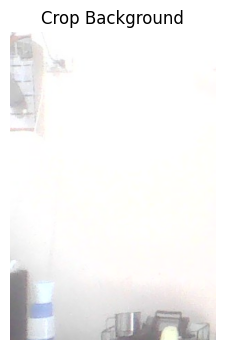

In [13]:
# Cropping background kiri
x_bg = 20
y_bg = 150
w_bg = 300
h_bg = 450

bg_crop_bgr = img_bgr[y_bg:y_bg+h_bg, x_bg:x_bg+w_bg]
bg_crop_rgb = cv2.cvtColor(bg_crop_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,4))
plt.imshow(bg_crop_rgb)
plt.title("Crop Background")
plt.axis("off")
plt.show()


### Resize hasil crop menjadi **920×920 piksel**.

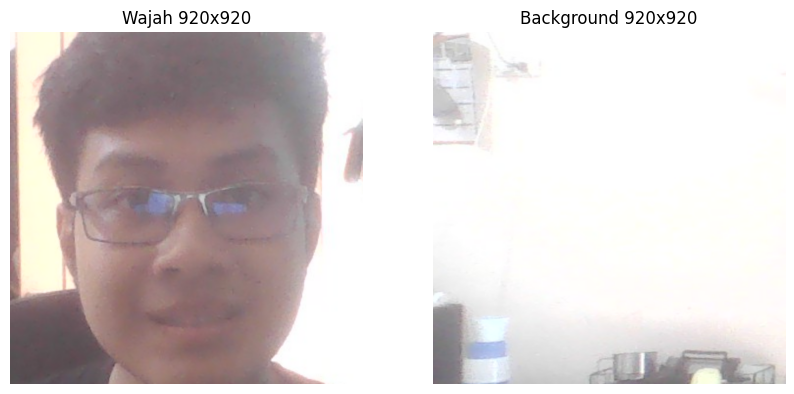

In [14]:
target_size = (920, 920)

face_resized_bgr = cv2.resize(face_crop_bgr, target_size)
bg_resized_bgr   = cv2.resize(bg_crop_bgr, target_size)

face_resized_rgb = cv2.cvtColor(face_resized_bgr, cv2.COLOR_BGR2RGB)
bg_resized_rgb   = cv2.cvtColor(bg_resized_bgr, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(face_resized_rgb); ax[0].set_title("Wajah 920x920"); ax[0].axis("off")
ax[1].imshow(bg_resized_rgb);   ax[1].set_title("Background 920x920"); ax[1].axis("off")
plt.show()


### Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.

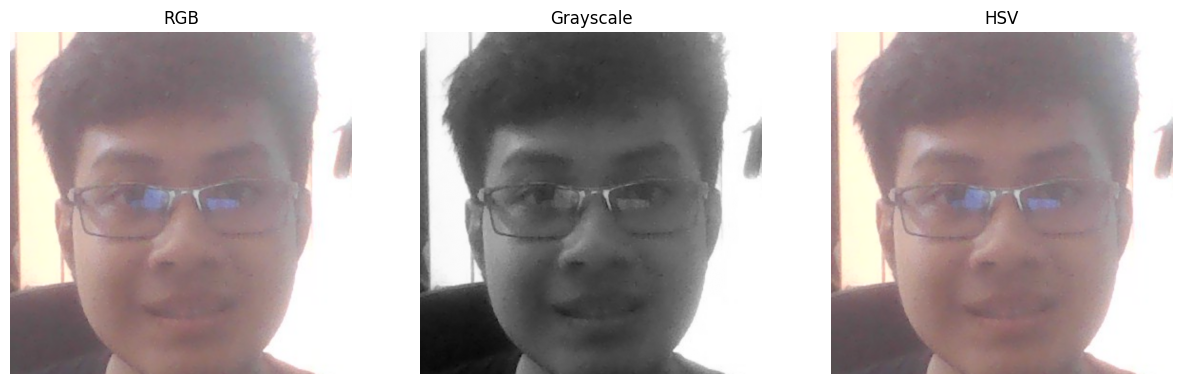

In [15]:
face_gray = cv2.cvtColor(face_resized_bgr, cv2.COLOR_BGR2GRAY)
face_hsv  = cv2.cvtColor(face_resized_bgr, cv2.COLOR_BGR2HSV)
face_hsv_rgb = cv2.cvtColor(face_hsv, cv2.COLOR_HSV2RGB)

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(face_resized_rgb); ax[0].set_title("RGB"); ax[0].axis("off")
ax[1].imshow(face_gray, cmap="gray"); ax[1].set_title("Grayscale"); ax[1].axis("off")
ax[2].imshow(face_hsv_rgb); ax[2].set_title("HSV"); ax[2].axis("off")
plt.show()


### Tambah anotasi teks (nama) di atas kepala

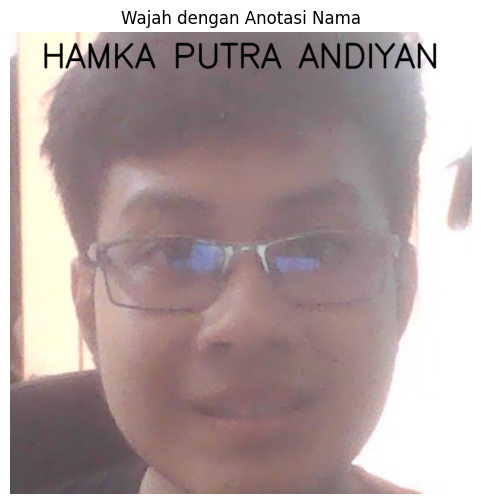

In [17]:
face_annotated = face_resized_bgr.copy()

text = "HAMKA PUTRA ANDIYAN"      # GANTI DENGAN NAMAMU
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 2.2
thickness = 4
color = (0,0,0)   # Hijau

(text_w, text_h), baseline = cv2.getTextSize(text, font, font_scale, thickness)
x_text = (face_annotated.shape[1] - text_w) // 2
y_text = 70

cv2.putText(face_annotated, text, (x_text, y_text), font, 
            font_scale, color, thickness, cv2.LINE_AA)

face_annotated_rgb = cv2.cvtColor(face_annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(face_annotated_rgb)
plt.title("Wajah dengan Anotasi Nama")
plt.axis("off")
plt.show()


### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


### Konversi gambar ke RGB

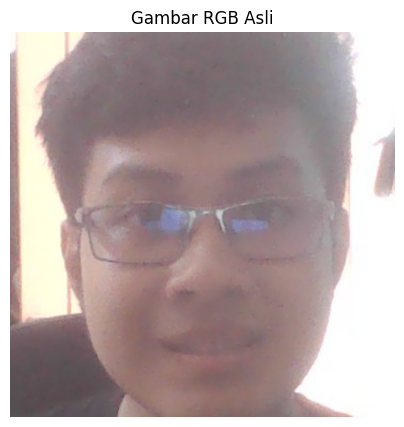

In [18]:
# Konversi BGR → RGB
img_rgb = cv2.cvtColor(face_resized_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title("Gambar RGB Asli")
plt.axis("off")
plt.show()


Menggunakan COLORBGR2RGB kita merubah penggunaan Blue green red menjadi RED GREEN BLUE

### Lakukan manipulasi channel warna

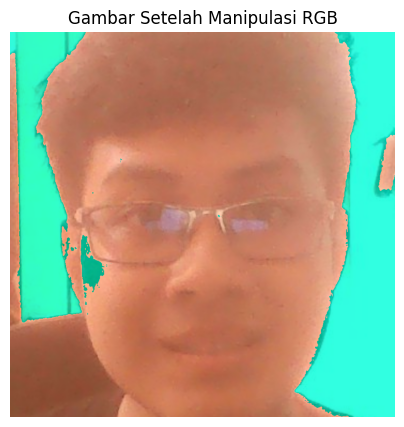

In [19]:
# Pisahkan channel
R, G, B = cv2.split(img_rgb)

# Manipulasi sesuai soal
R_mod = np.clip(R + 50, 0, 255)   # Naikkan merah 50
B_mod = np.clip(B - 30, 0, 255)   # Turunkan biru 30
G_mod = G.copy()                  # Channel hijau tidak berubah

# Gabungkan kembali
img_rgb_mod = cv2.merge([R_mod, G_mod, B_mod])

plt.figure(figsize=(5,5))
plt.imshow(img_rgb_mod)
plt.title("Gambar Setelah Manipulasi RGB")
plt.axis("off")
plt.show()


Setelah di lakukan manipulasi warna RED terlihat lebih intens dan warna biru memudar dari warna aslinya

### Simpan hasil dalam format PNG

In [20]:
# Ubah dari RGB → BGR sebelum disimpan karena OpenCV menggunakan BGR
img_bgr_mod = cv2.cvtColor(img_rgb_mod, cv2.COLOR_RGB2BGR)

cv2.imwrite("hasil_manipulasi_rgb.png", img_bgr_mod)

print("Gambar berhasil disimpan sebagai hasil_manipulasi_rgb.png")


Gambar berhasil disimpan sebagai hasil_manipulasi_rgb.png


### Tampilkan Histogram RGB (Sebelum & Sesudah)

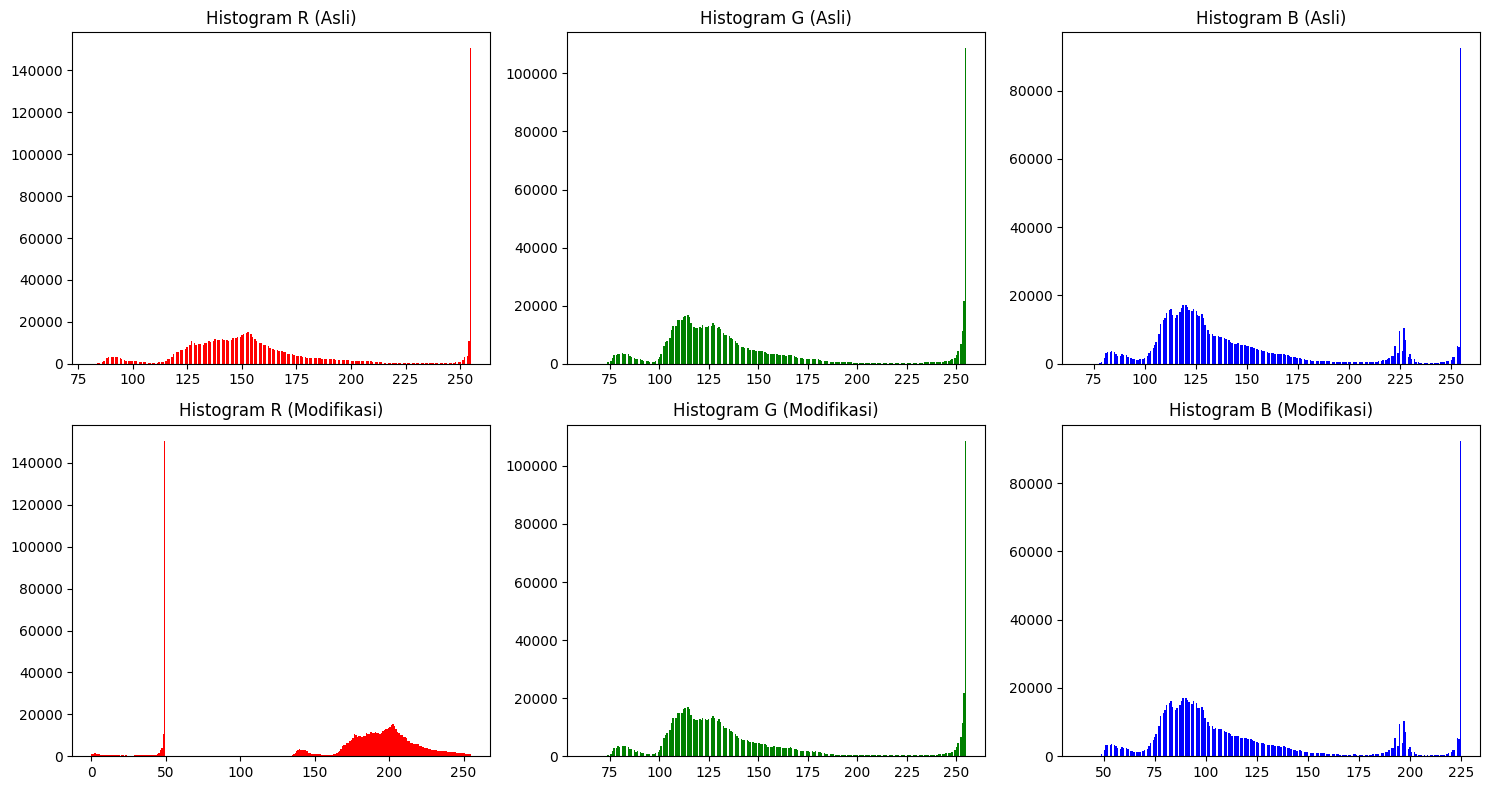

In [21]:
# Membuat histogram untuk tiap channel
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Histogram ASLI
axes[0,0].hist(R.ravel(), bins=256, color='red')
axes[0,0].set_title("Histogram R (Asli)")

axes[0,1].hist(G.ravel(), bins=256, color='green')
axes[0,1].set_title("Histogram G (Asli)")

axes[0,2].hist(B.ravel(), bins=256, color='blue')
axes[0,2].set_title("Histogram B (Asli)")

# Histogram MODIFIKASI
axes[1,0].hist(R_mod.ravel(), bins=256, color='red')
axes[1,0].set_title("Histogram R (Modifikasi)")

axes[1,1].hist(G_mod.ravel(), bins=256, color='green')
axes[1,1].set_title("Histogram G (Modifikasi)")

axes[1,2].hist(B_mod.ravel(), bins=256, color='blue')
axes[1,2].set_title("Histogram B (Modifikasi)")

plt.tight_layout()
plt.show()


#### Dampak Secara Histogram
Histogram **R** bergeser ke kanan → intensitas meningkat.
Histogram **B** bergeser sedikit ke kiri → intensitas menurun.
Histogram **G** tidak berubah.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


### Gambar bertekstur

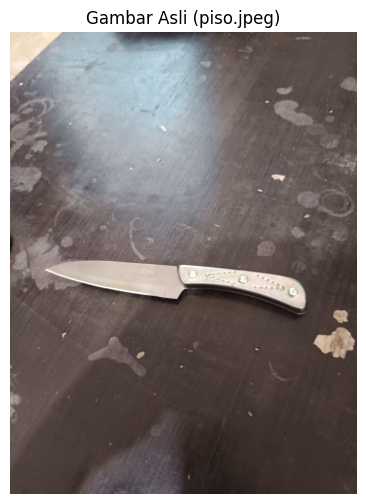

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar objek bertekstur
img_bgr = cv2.imread("piso.jpeg")  # pastikan nama file benar
if img_bgr is None:
    raise FileNotFoundError("File 'piso.jpeg' tidak ditemukan. Taruh di folder yang sama dengan notebook.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Gambar Asli (piso.jpeg)")
plt.axis("off")
plt.show()


### Edge Detection

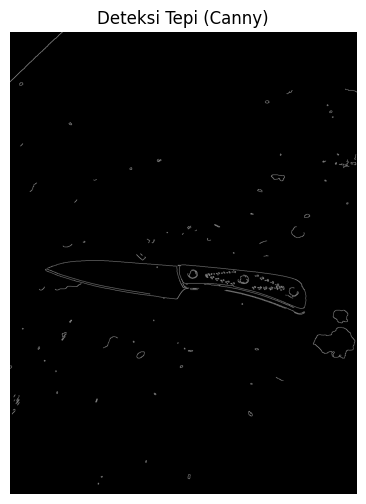

In [34]:
# Konversi ke grayscale
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Deteksi tepi Canny
edges = cv2.Canny(gray, 100, 200)  # threshold bisa diubah kalau perlu

plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap="gray")
plt.title("Deteksi Tepi (Canny)")
plt.axis("off")
plt.show()


Deteksi Tepi (Canny)
- Metode Canny mencari perubahan intensitas yang tajam pada citra (gradien tinggi).
- Pada gambar dengan background bertekstur, Canny:
  - Menonjolkan garis-garis tepi objek utama (kontur bentuk objek).
  - Juga menampilkan tepi-tepi kecil pada tekstur background (misalnya pola kain/batu).
- Hasilnya berupa citra biner (hitam-putih) di mana garis tepi berwarna putih.

### Tresholding 

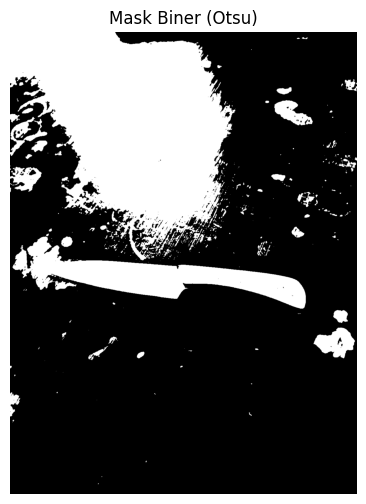

In [35]:
# Thresholding otomatis dengan Otsu
# Objek dan background dipisah berdasarkan intensitas
_, mask = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title("Mask Biner (Otsu)")
plt.axis("off")
plt.show()


 Thresholding dan Segmentasi
- Thresholding mengubah citra grayscale menjadi citra biner berdasarkan nilai ambang T.
- Piksel dengan intensitas:
  - Di atas T menjadi putih (255).
  - Di bawah T menjadi hitam (0), atau sebaliknya jika menggunakan THRESH_BINARY_INV.
- Dengan pemilihan T yang tepat:
  - Objek utama dapat dipisahkan dari background bertekstur.
  - Dari mask biner tersebut, objek utama bisa dicari menggunakan kontur terbesar.
- Bounding box dibuat mengelilingi kontur terbesar, sehingga area objek utama dapat ditandai dengan jelas.


### Bounding Box

In [37]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

thresh_value = 120
_, thresh = cv2.threshold(gray, thresh_value, 255, cv2.THRESH_BINARY)
_, thresh_inv = cv2.threshold(gray, thresh_value, 255, cv2.THRESH_BINARY_INV)


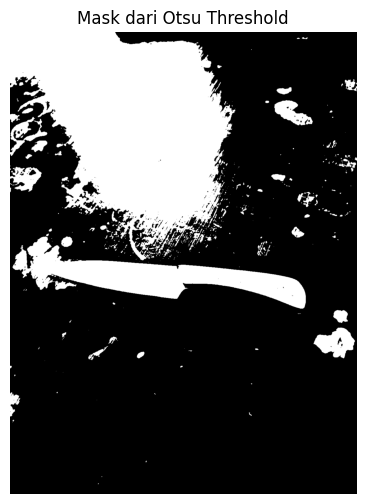

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar
img_bgr = cv2.imread("piso.jpeg")
if img_bgr is None:
    raise FileNotFoundError("File 'piso.jpeg' tidak ditemukan.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Thresholding otomatis Otsu
_, mask = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Mask dari Otsu Threshold")
plt.axis("off")
plt.show()


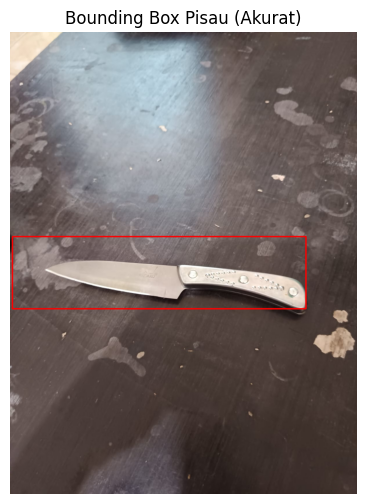

In [45]:
# Cari semua kontur
contours, hierarchy = cv2.findContours(
    mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

possible_knives = []

for c in contours:
    x, y, w_box, h_box = cv2.boundingRect(c)
    area = cv2.contourArea(c)

    # Skip area terlalu kecil (noise)
    if area < 2000:
        continue

    # Rasio panjang-lebar (pisau cenderung panjang)
    aspect_ratio = w_box / float(h_box)

    # Pisau biasanya punya rasio >= 2.5
    if aspect_ratio >= 2.5:
        possible_knives.append((c, area, aspect_ratio))

# Jika tidak ada kandidat, fallback (tapi seharusnya ada)
if len(possible_knives) == 0:
    main_contour = max(contours, key=cv2.contourArea)
else:
    # Pilih kontur dengan area terbesar dari kandidat valid
    main_contour = max(possible_knives, key=lambda x: x[1])[0]

# Bounding box final
x, y, w_box, h_box = cv2.boundingRect(main_contour)

# Visualisasi
bb_img = img_rgb.copy()
cv2.rectangle(bb_img, (x, y), (x + w_box, y + h_box), (255, 0, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(bb_img)
plt.title("Bounding Box Pisau (Akurat)")
plt.axis("off")
plt.show()


### Penjelasan Bounding Box pada Objek Pisau

Hasil thresholding menggunakan metode Otsu menghasilkan mask biner yang memisahkan objek terang dan gelap pada gambar. Namun, pada permukaan meja terdapat banyak noda dan bercak terang yang bentuknya tidak beraturan. Bercak-bercak ini ikut terdeteksi sebagai objek putih dalam mask, dan beberapa di antaranya memiliki area yang lebih besar daripada pisau. Jika kita langsung memilih kontur dengan area terbesar, bounding box akan salah karena lebih cenderung mengikuti area noda pada meja, bukan objek pisau.

Untuk mendapatkan bounding box yang benar-benar mengelilingi pisau, digunakan pendekatan berbasis *aspect ratio* dari kontur. Pisau memiliki bentuk yang memanjang, sehingga rasio panjang terhadap lebar (width/height) cukup besar—umumnya di atas 2.5. Sementara itu, noda atau bercak pada meja cenderung memiliki bentuk yang lebih bulat atau acak sehingga rasio panjang-lebarnya kecil.

Dengan menyaring kontur menggunakan kriteria area minimum dan rasio panjang-lebar, kita dapat mengeliminasi noda-noda meja dan memilih kontur yang paling mungkin merupakan pisau. Pendekatan ini membuat bounding box menjadi lebih akurat dan fokus pada objek utama sesuai yang diminta oleh soal.


### Filter Blur dan Sharpening + Perbandingan

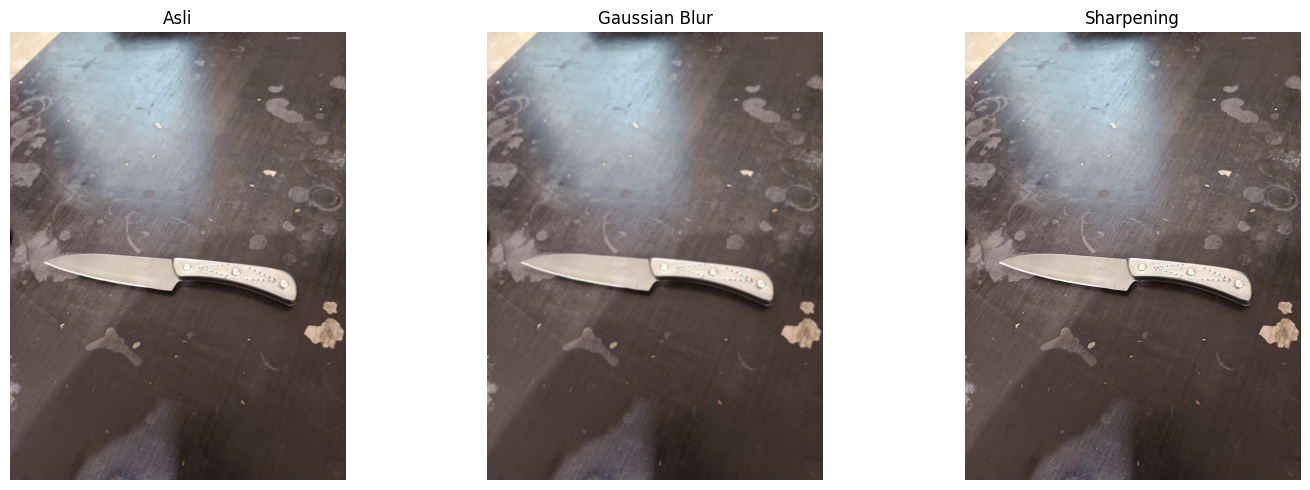

In [46]:
# Gaussian blur
blurred = cv2.GaussianBlur(img_rgb, (9, 9), 0)

# Kernel sharpening sederhana
sharpen_kernel = np.array([[0, -1,  0],
                           [-1, 5, -1],
                           [0, -1,  0]])

sharpened = cv2.filter2D(img_rgb, -1, sharpen_kernel)

# Tampilkan berdampingan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Asli")
axes[0].axis("off")

axes[1].imshow(blurred)
axes[1].set_title("Gaussian Blur")
axes[1].axis("off")

axes[2].imshow(sharpened)
axes[2].set_title("Sharpening")
axes[2].axis("off")

plt.tight_layout()
plt.show()


#### 5. Perbandingan Blur vs Sharpening
- **Blur**:
  - Mengurangi detail dan noise.
  - Cocok untuk smoothing, pra-proses sebelum segmentasi atau mengurangi tekstur yang terlalu ramai.
- **Sharpening**:
  - Meningkatkan ketajaman detail dan kontur.
  - Cocok untuk menonjolkan bentuk objek, tetapi harus hati-hati agar noise tidak ikut muncul kuat.
- Pada gambar dengan background bertekstur:
  - Blur membuat tekstur background kurang terlihat, fokus pada bentuk global saja.
  - Sharpening justru membuat tekstur background semakin menonjol, sehingga gambar tampak lebih detail tetapi juga berpotensi lebih ramai.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

In [ ]:
!pip install opencv-python mediapipe matplotlib numpy

### Import & deteksi wajah + landmark (MediaPipe)

In [ ]:
!pip install --user mediapipe


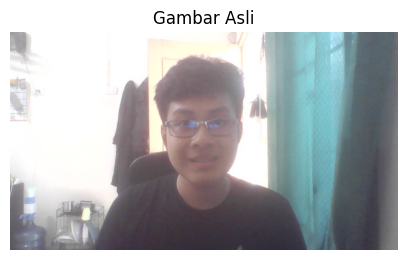

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load foto wajah netral
img_bgr = cv2.imread("selfie.jpg")
if img_bgr is None:
    raise FileNotFoundError("File 'selfie.jpg' tidak ditemukan.")

h, w = img_bgr.shape[:2]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")
plt.show()


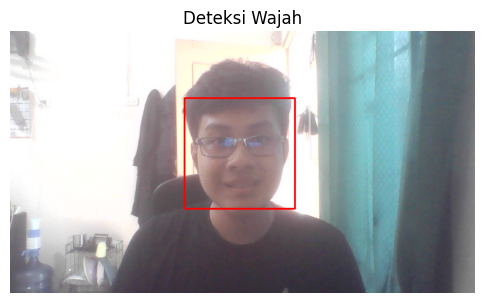

In [74]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar selfie
img_bgr = cv2.imread("selfie.jpg")
if img_bgr is None:
    raise FileNotFoundError("File 'selfie.jpg' tidak ditemukan.")

# --- 1. Perkecil gambar biar Haar Cascade lebih akurat ---
scale = 0.5
small_bgr = cv2.resize(img_bgr, None, fx=scale, fy=scale)

# --- 2. Perbaiki kontras (sangat penting untuk foto kamu) ---
gray = cv2.cvtColor(small_bgr, cv2.COLOR_BGR2GRAY)
gray_eq = cv2.equalizeHist(gray)

# --- 3. Pakai Haar model yg lebih kuat ---
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml"
)

faces_small = face_cascade.detectMultiScale(
    gray_eq,
    scaleFactor=1.05,
    minNeighbors=3,
    minSize=(60, 60)
)

if len(faces_small) == 0:
    raise ValueError("Tetap tidak terdeteksi, tapi harusnya sekarang sudah.")

# Ambil wajah terbesar (pasti benar)
x_s, y_s, w_s, h_s = max(faces_small, key=lambda f: f[2]*f[3])

# --- 4. Konversi koordinat kembali ke ukuran asli ---
x = int(x_s / scale)
y = int(y_s / scale)
w_face = int(w_s / scale)
h_face = int(h_s / scale)

# --- Visualisasi: bounding box DETEKSI WAJAH BERHASIL ---
img_vis = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
cv2.rectangle(img_vis, (x, y), (x + w_face, y + h_face), (255, 0, 0), 3)

plt.figure(figsize=(6,6))
plt.imshow(img_vis)
plt.title("Deteksi Wajah")
plt.axis("off")
plt.show()


### Overlay kumis ke wajah dengan alpha blending

Center kumis : 632 381
Ukuran kumis : 212 x 60


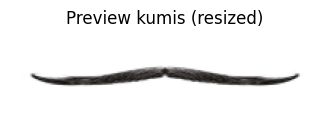

In [78]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

h, w = img_bgr.shape[:2]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Pusat wajah
cx = x + w_face // 2
# Posisi vertikal kumis: sekitar 65% tinggi wajah dari atas
cy = y + int(h_face * 0.65)

# Ukuran kumis proporsional terhadap wajah
mustache_width  = int(w_face * 0.7)
mustache_height = int(h_face * 0.20)

print("Center kumis :", cx, cy)
print("Ukuran kumis :", mustache_width, "x", mustache_height)

# Load kumis.jpg
mustache = cv2.imread("kumis.jpg", cv2.IMREAD_UNCHANGED)
if mustache is None:
    raise FileNotFoundError("File 'kumis.jpg' tidak ditemukan.")

# Kalau kumis.jpg tidak punya alpha (3 channel), buat alpha dari background terang
if mustache.shape[2] == 3:
    gray_m = cv2.cvtColor(mustache, cv2.COLOR_BGR2GRAY)
    # Anggap background putih/terang → jadi transparan
    _, alpha = cv2.threshold(gray_m, 250, 255, cv2.THRESH_BINARY_INV)
    mustache = cv2.cvtColor(mustache, cv2.COLOR_BGR2BGRA)
    mustache[:, :, 3] = alpha

# Resize kumis ke ukuran sesuai wajah
mustache_resized = cv2.resize(
    mustache, (mustache_width, mustache_height),
    interpolation=cv2.INTER_AREA
)

plt.figure(figsize=(4,3))
plt.imshow(cv2.cvtColor(mustache_resized[:,:,:3], cv2.COLOR_BGR2RGB))
plt.title("Preview kumis (resized)")
plt.axis("off")
plt.show()


### Buat overlay filter kreatif (kumis) + alpha blending

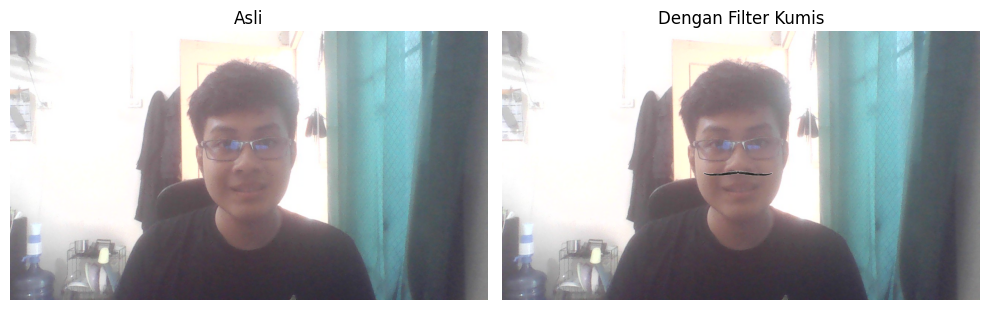

In [79]:
# Konversi foto asli ke BGRA
base_bgra = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2BGRA)

mh, mw = mustache_resized.shape[:2]

# Posisi kiri-atas & kanan-bawah kumis di gambar
x1 = cx - mw // 2
y1 = cy - mh // 2
x2 = x1 + mw
y2 = y1 + mh

# Clip supaya tidak keluar frame
x1_clip = max(x1, 0)
y1_clip = max(y1, 0)
x2_clip = min(x2, w)
y2_clip = min(y2, h)

# Offset pada gambar kumis (kalau kena clip)
overlay_x1 = x1_clip - x1
overlay_y1 = y1_clip - y1
overlay_x2 = overlay_x1 + (x2_clip - x1_clip)
overlay_y2 = overlay_y1 + (y2_clip - y1_clip)

# Region of Interest di gambar asli & kumis
roi = base_bgra[y1_clip:y2_clip, x1_clip:x2_clip]
mustache_roi = mustache_resized[overlay_y1:overlay_y2, overlay_x1:overlay_x2]

# Pisahkan channel
overlay_rgb = mustache_roi[:, :, :3].astype(float)
alpha_m = mustache_roi[:, :, 3].astype(float) / 255.0
alpha_m_3 = np.stack([alpha_m]*3, axis=-1)

roi_rgb = roi[:, :, :3].astype(float)

# Alpha blending: hasil = α*overlay + (1-α)*background
blended_rgb = alpha_m_3 * overlay_rgb + (1 - alpha_m_3) * roi_rgb
roi[:, :, :3] = blended_rgb.astype(np.uint8)

# Kembali ke BGR untuk disimpan / ditampilkan
result_bgr = cv2.cvtColor(base_bgra, cv2.COLOR_BGRA2BGR)
result_rgb = cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB)

# Tampilkan perbandingan
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_rgb);    ax[0].set_title("Asli"); ax[0].axis("off")
ax[1].imshow(result_rgb); ax[1].set_title("Dengan Filter Kumis"); ax[1].axis("off")
plt.tight_layout()
plt.show()


### Deteksi Wajah dan Filter Kumis (OpenCV)

- Wajah dideteksi menggunakan **OpenCV Haar Cascade** (`haarcascade_frontalface_alt2.xml`) dengan gambar yang terlebih dulu:
  - Diresize agar wajah tampak lebih besar relatif terhadap frame.
  - Ditingkatkan kontrasnya (equalize histogram) supaya fitur wajah lebih jelas meskipun backlight kuat.
- Dari hasil deteksi saya memperoleh bounding box wajah `(x, y, w_face, h_face)` dan menggunakan informasi ini untuk menghitung posisi kumis:
  - Titik tengah wajah secara horizontal (`cx = x + w_face/2`) dipakai sebagai pusat kumis.
  - Posisi vertikal kumis diletakkan di sekitar **65% tinggi wajah** (`cy = y + 0.65*h_face`), yaitu di daerah mulut dan bawah hidung.
- Ukuran kumis dibuat proporsional terhadap wajah:
  - Lebar kumis ≈ **70% lebar wajah**.
  - Tinggi kumis ≈ **20% tinggi wajah**, sehingga bentuknya tidak terlalu besar atau terlalu kecil.
- Gambar `kumis.jpg` dibaca dan di-resize ke ukuran tersebut. Karena format JPG biasanya tidak punya kanal alpha, saya membuat **mask alpha** sendiri:
  - Gambar diubah ke grayscale, kemudian dilakukan threshold sehingga bagian background yang sangat terang dianggap transparan, dan bagian kumis dianggap opak.
  - Hasil threshold ini dimasukkan sebagai channel alpha pada citra BGRA.
- Overlay kumis dilakukan dengan **alpha blending** pada region of interest (ROI) di sekitar mulut:
  - Untuk setiap piksel dihitung `output = alpha * warna_kumis + (1 - alpha) * warna_wajah`.
  - Dengan cara ini, tepi kumis menjadi halus dan menyatu dengan warna kulit, tidak terlihat seperti tempelan kotak.
- Tantangan yang dihadapi:
  - Wajah pada foto mengalami backlight sehingga awalnya Haar Cascade gagal mendeteksi wajah; hal ini diatasi dengan resize dan peningkatan kontras.
  - Penentuan posisi vertikal kumis perlu beberapa percobaan agar tidak menutupi bibir dan tetap berada tepat di bawah hidung.
  - Karena `kumis.jpg` tidak memiliki alpha transparan secara bawaan, perlu dibuat kanal alpha manual dari intensitas piksel agar background kumis tidak menutupi wajah.


### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

### Import & load

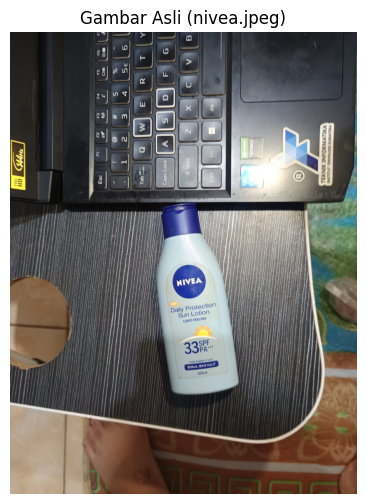

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar nivea
img_bgr = cv2.imread("nivea.jpeg")
if img_bgr is None:
    raise FileNotFoundError("File 'nivea.jpeg' tidak ditemukan.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Gambar Asli (nivea.jpeg)")
plt.axis("off")
plt.show()


### Konversi ke grayscale

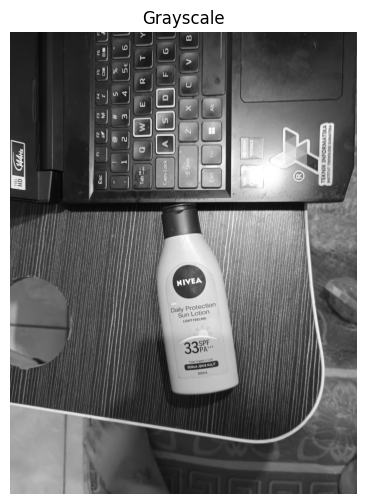

In [81]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()


In [89]:
import cv2
import numpy as np

img = cv2.imread("nivea.jpeg")
if img is None:
    raise FileNotFoundError("File 'nivea.jpeg' tidak ditemukan.")

# Resize gambar agar pas di layar
max_h, max_w = 800, 600   # ubah ukuran sesuai layar kamu
h, w = img.shape[:2]

scale = min(max_w / w, max_h / h)
img_small = cv2.resize(img, (int(w*scale), int(h*scale)))

clone = img_small.copy()
pts_src = []

def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        pts_src.append((x, y))
        cv2.circle(clone, (x, y), 4, (0,0,255), -1)
        cv2.imshow("Klik 4 Titik (kiri-atas → kanan-atas → kanan-bawah → kiri-bawah)", clone)
        print("Titik:", (x, y))

cv2.namedWindow("Klik 4 Titik (kiri-atas → kanan-atas → kanan-bawah → kiri-bawah)", cv2.WINDOW_AUTOSIZE)
cv2.imshow("Klik 4 Titik (kiri-atas → kanan-atas → kanan-bawah → kiri-bawah)", clone)
cv2.setMouseCallback("Klik 4 Titik (kiri-atas → kanan-atas → kanan-bawah → kiri-bawah)", click_event)

print("Klik 4 titik sudut objek, lalu tekan ESC")

while True:
    if cv2.waitKey(1) & 0xFF == 27:  # ESC
        break

cv2.destroyAllWindows()

print("Titik final (versi kecil):", pts_src)

# Konversi titik kecil ke ukuran asli
pts_src_full = [(int(x/scale), int(y/scale)) for (x,y) in pts_src]
print("Titik dalam ukuran asli:", pts_src_full)


Klik 4 titik sudut objek, lalu tekan ESC
Titik: (138, 312)
Titik: (453, 282)
Titik: (186, 673)
Titik: (527, 615)


KeyboardInterrupt: 

Titik pada ukuran asli:
 [[ 276.  624.]
 [ 906.  564.]
 [1054. 1230.]
 [ 372. 1346.]]


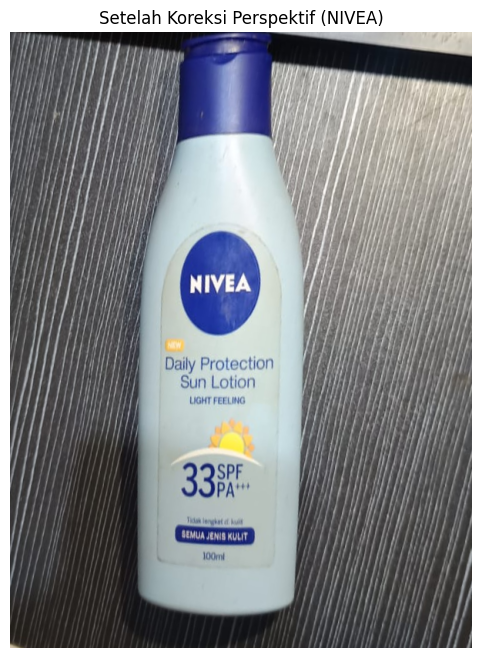

In [91]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load gambar asli ---
img_bgr = cv2.imread("nivea.jpeg")
if img_bgr is None:
    raise FileNotFoundError("File 'nivea.jpeg' tidak ditemukan.")

h, w = img_bgr.shape[:2]

# --- SAMAKAN dengan yang dipakai waktu resize untuk klik titik ---
max_h, max_w = 800, 600   # kalau di kode klik tadi beda, samakan di sini

scale = min(max_w / w, max_h / h)

# Titik yang kamu klik di gambar kecil (urutan: LT, RT, RB, LB)
pts_src_small = np.float32([
    [138, 312],  # kiri atas
    [453, 282],  # kanan atas
    [527, 615],  # kanan bawah
    [186, 673],  # kiri bawah
])

# Konversi ke koordinat ukuran asli
pts_src = []
for (xs, ys) in pts_src_small:
    x_full = xs / scale
    y_full = ys / scale
    pts_src.append([x_full, y_full])
pts_src = np.float32(pts_src)

print("Titik pada ukuran asli:\n", pts_src)

# Ukuran output yang lurus
width, height = 600, 800
pts_dst = np.float32([[0,0], [width,0], [width,height], [0,height]])

# Homografi & warp
H = cv2.getPerspectiveTransform(pts_src, pts_dst)
warped_bgr = cv2.warpPerspective(img_bgr, H, (width, height))
warped_rgb = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,8))
plt.imshow(warped_rgb)
plt.title("Setelah Koreksi Perspektif (NIVEA)")
plt.axis("off")
plt.show()


### Grayscale + adaptive threshold + grid

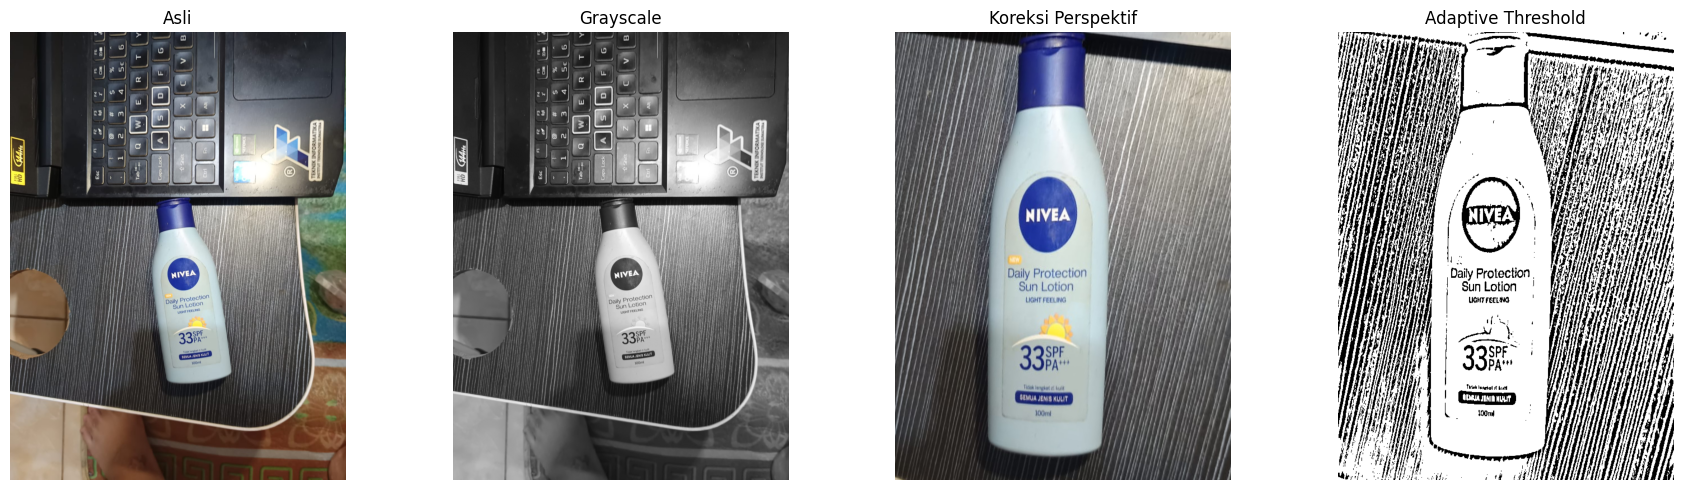

In [92]:
# Grayscale asli
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Grayscale hasil warp
gray_warped = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY)

# Adaptive threshold (cocok buat cahaya nggak rata)
th_adaptive = cv2.adaptiveThreshold(
    gray_warped,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    25, 10
)

# Grid 4 tahap
fig, ax = plt.subplots(1, 4, figsize=(18,5))

ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
ax[0].set_title("Asli")
ax[0].axis("off")

ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Grayscale")
ax[1].axis("off")

ax[2].imshow(warped_rgb)
ax[2].set_title("Koreksi Perspektif")
ax[2].axis("off")

ax[3].imshow(th_adaptive, cmap="gray")
ax[3].set_title("Adaptive Threshold")
ax[3].axis("off")

plt.tight_layout()
plt.show()


### Penjelasan Tahapan Peningkatan Kualitas Citra 

- **Grayscale**
  - Mengubah citra berwarna menjadi satu kanal intensitas.
  - Mengurangi kompleksitas data sehingga proses berikutnya (perspektif dan thresholding) lebih sederhana.
  - Fokus pada informasi terang–gelap yang penting untuk membaca teks dan pola pada kemasan.

- **Koreksi Perspektif (Homografi dengan 4 titik)**
  - Saya memilih 4 titik sudut kemasan Nivea (kiri-atas, kanan-atas, kanan-bawah, kiri-bawah).
  - Titik-titik tersebut dipetakan ke sudut gambar tujuan yang berbentuk persegi panjang teratur (misalnya 600×800 piksel).
  - Dengan matriks homografi, bidang miring pada foto dikoreksi sehingga kemasan tampak lurus seperti hasil scan.
  - Hal ini mengurangi distorsi perspektif dan membuat teks/logo lebih mudah dibaca.

- **Adaptive Threshold**
  - Kondisi pencahayaan pada foto produk di meja biasanya tidak merata (ada bagian yang lebih terang dan lebih gelap).
  - Karena itu saya memilih **adaptive threshold** dibanding Otsu:
    - Otsu memakai satu nilai ambang global untuk seluruh gambar, kurang cocok bila pencahayaan tidak seragam.
    - Adaptive threshold menghitung nilai ambang secara lokal di setiap blok kecil citra.
  - Hasilnya, tulisan dan kontur kemasan menjadi sangat kontras (hitam-putih) meskipun ada variasi cahaya di permukaan.

- **Grid Tahapan (Asli → Grayscale → Perspektif → Threshold)**
  - Menampilkan semua tahap dalam satu grid memudahkan untuk melihat efek setiap proses:
    - Dari foto asli yang miring dan tidak ideal.
    - Menjadi grayscale yang lebih fokus pada luminansi.
    - Menjadi citra yang sudah diluruskan secara geometris.
    - Hingga citra biner yang sangat kontras mirip hasil pemindaian dokumen.
  - Kombinasi tahapan ini meningkatkan kualitas visual citra dan membuat konten pada kemasan Nivea menjadi lebih jelas dan rapi.


# Penggunaan akal imitasi


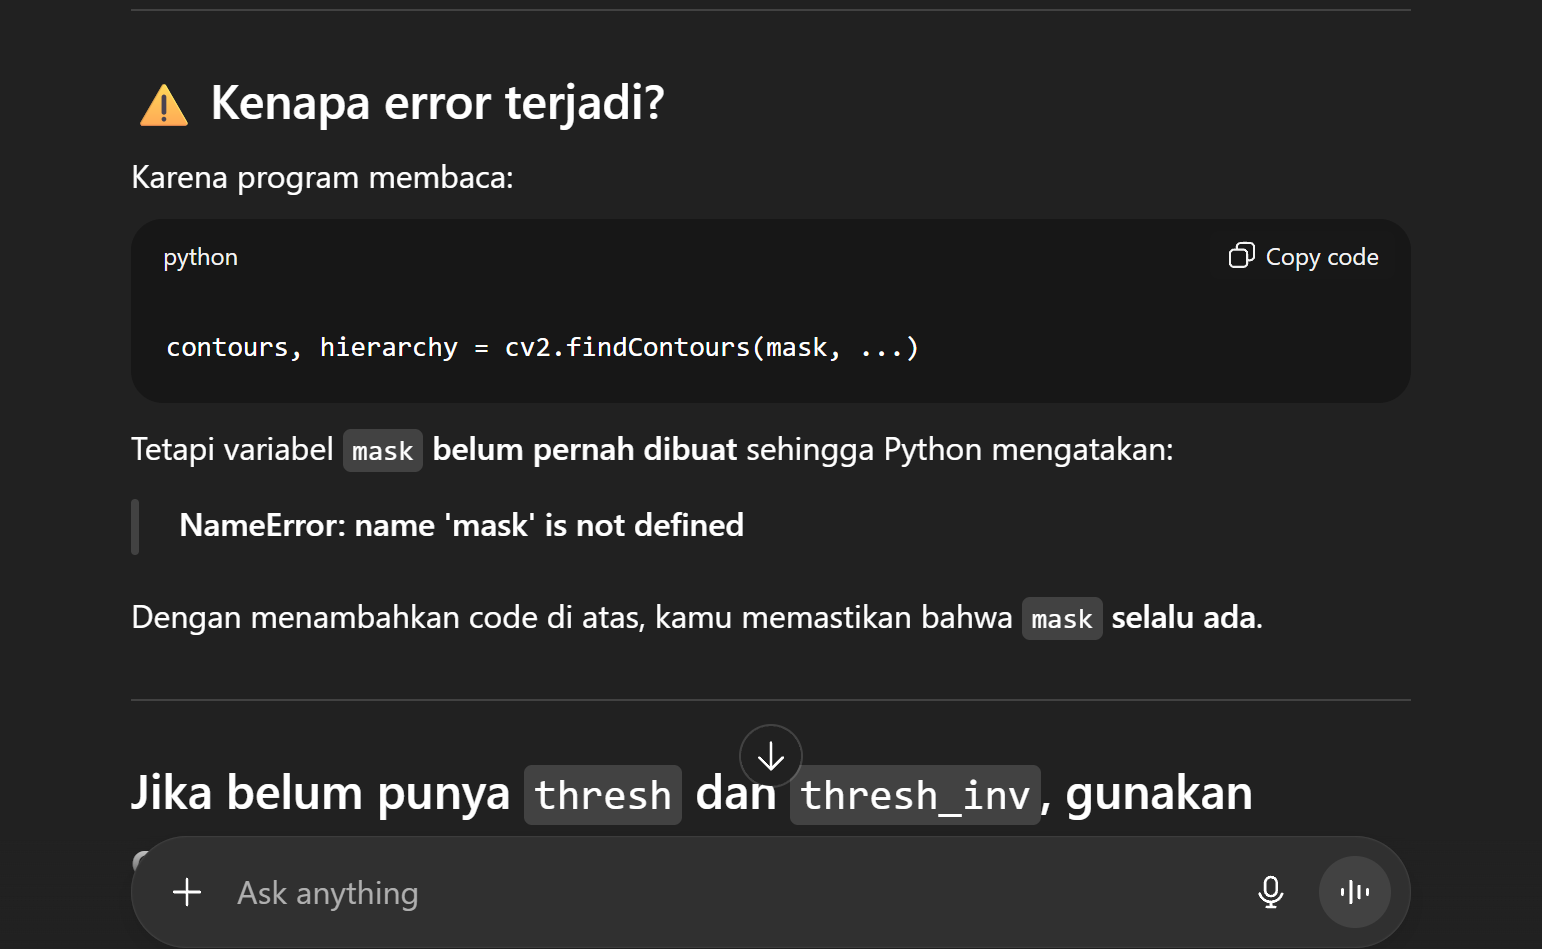

In [9]:
from PIL import Image
from IPython.display import display

img = Image.open("assets_ws4/akalimitasi.png")
display(img)


### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.